# LeetCode #701: Insert into a Binary Search Tree

https://leetcode.com/problems/insert-into-a-binary-search-tree/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (in-order scan)** | $O(n)$ | $O(n)$ |
| **Optimal: Iterative BST Insertion ★** | $O(h)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (in-order scan)
Collect all nodes into a sorted list, insert the new value, then rebuild the tree. Requires $O(n)$ time and space regardless of tree height.

### Optimal: Iterative BST Insertion ★
Traverse left or right at each node according to the BST property until finding a null child slot. Attach the new node there. No recursion stack needed, so space is $O(1)$ and time is $O(h)$ where $h$ is the tree height.

**Why this is better than Brute Force:** We exploit the BST ordering to skip the irrelevant subtree at every step, reducing work from $O(n)$ to $O(h)$.

**Constraints:**
* The number of nodes in the tree is in the range $[0, 10^4]$
* $-10^8 \le \text{Node.val} \le 10^8$
* All the values `Node.val` are unique
* $-10^8 \le \text{val} \le 10^8$
* It is guaranteed that `val` does not exist in the original BST


## Solutions

### C#

In [ ]:
public TreeNode InsertIntoBST(TreeNode root, int val) {
    TreeNode node = new TreeNode(val);
    if (root == null) return node;
    TreeNode curr = root;
    while (true) {
        if (val < curr.val) {
            // Navigate to the null slot in the left subtree
            if (curr.left == null) { curr.left = node; break; }
            curr = curr.left;
        } else {
            // Navigate to the null slot in the right subtree
            if (curr.right == null) { curr.right = node; break; }
            curr = curr.right;
        }
    }
    return root;
}

### Python

In [ ]:
def insert_into_bst(root, val: int):
    node = TreeNode(val)
    if not root:
        return node
    curr = root
    while True:
        if val < curr.val:
            # Navigate to the null slot in the left subtree
            if curr.left is None:
                curr.left = node
                break
            curr = curr.left
        else:
            # Navigate to the null slot in the right subtree
            if curr.right is None:
                curr.right = node
                break
            curr = curr.right
    return root

### Go

In [ ]:
func insertIntoBST(root *TreeNode, val int) *TreeNode {
    node := &TreeNode{Val: val}
    if root == nil { return node }
    curr := root
    for {
        if val < curr.Val {
            // Navigate to the null slot in the left subtree
            if curr.Left == nil { curr.Left = node; break }
            curr = curr.Left
        } else {
            // Navigate to the null slot in the right subtree
            if curr.Right == nil { curr.Right = node; break }
            curr = curr.Right
        }
    }
    return root
}

### Rust

In [ ]:
pub fn insert_into_bst(root: Option<Box<TreeNode>>, val: i32) -> Option<Box<TreeNode>> {
    match root {
        None => Some(Box::new(TreeNode::new(val))),
        Some(mut node) => {
            if val < node.val {
                // Navigate to the null slot in the left subtree
                node.left = Self::insert_into_bst(node.left.take(), val);
            } else {
                // Navigate to the null slot in the right subtree
                node.right = Self::insert_into_bst(node.right.take(), val);
            }
            Some(node)
        }
    }
}

## Example Scenarios

**1. Common Case**
**Input:** `root = [4,2,7,1,3], val = 5`
Traverse: 5 > 4 → go right to 7; 5 < 7 → go left, slot is null → insert 5 as left child of 7. Return original root. $O(h) = O(2)$ steps.

**2. Slightly Complex**
**Input:** `root = [40,20,60,10,30,50,70], val = 25`
Traverse: 25 < 40 → left (20); 25 > 20 → right (30); 25 < 30 → left, null → insert 25. Three hops down the tree.

**3. Edge Case: Time Factor**
**Input:** Skewed tree `[1,null,2,null,3,...,null,n], val = n+1`
The tree degenerates into a linked list. Insertion requires traversing all $n$ nodes to reach the rightmost null — worst-case $O(n) = O(h)$ for a skewed tree.

**4. Edge Case: Space Factor**
**Input:** `root = null, val = 42`
Empty tree. Immediately return a new node. No traversal needed — $O(1)$ time and space.

**5. Almost-Impossible but Plausible**
**Input:** `root = [10^8], val = 10^8 - 1`
Root holds the maximum allowed value. New value $10^8 - 1$ is less, so it goes left into the null slot. No overflow: comparison is between `i32` values within $\pm 10^8$.


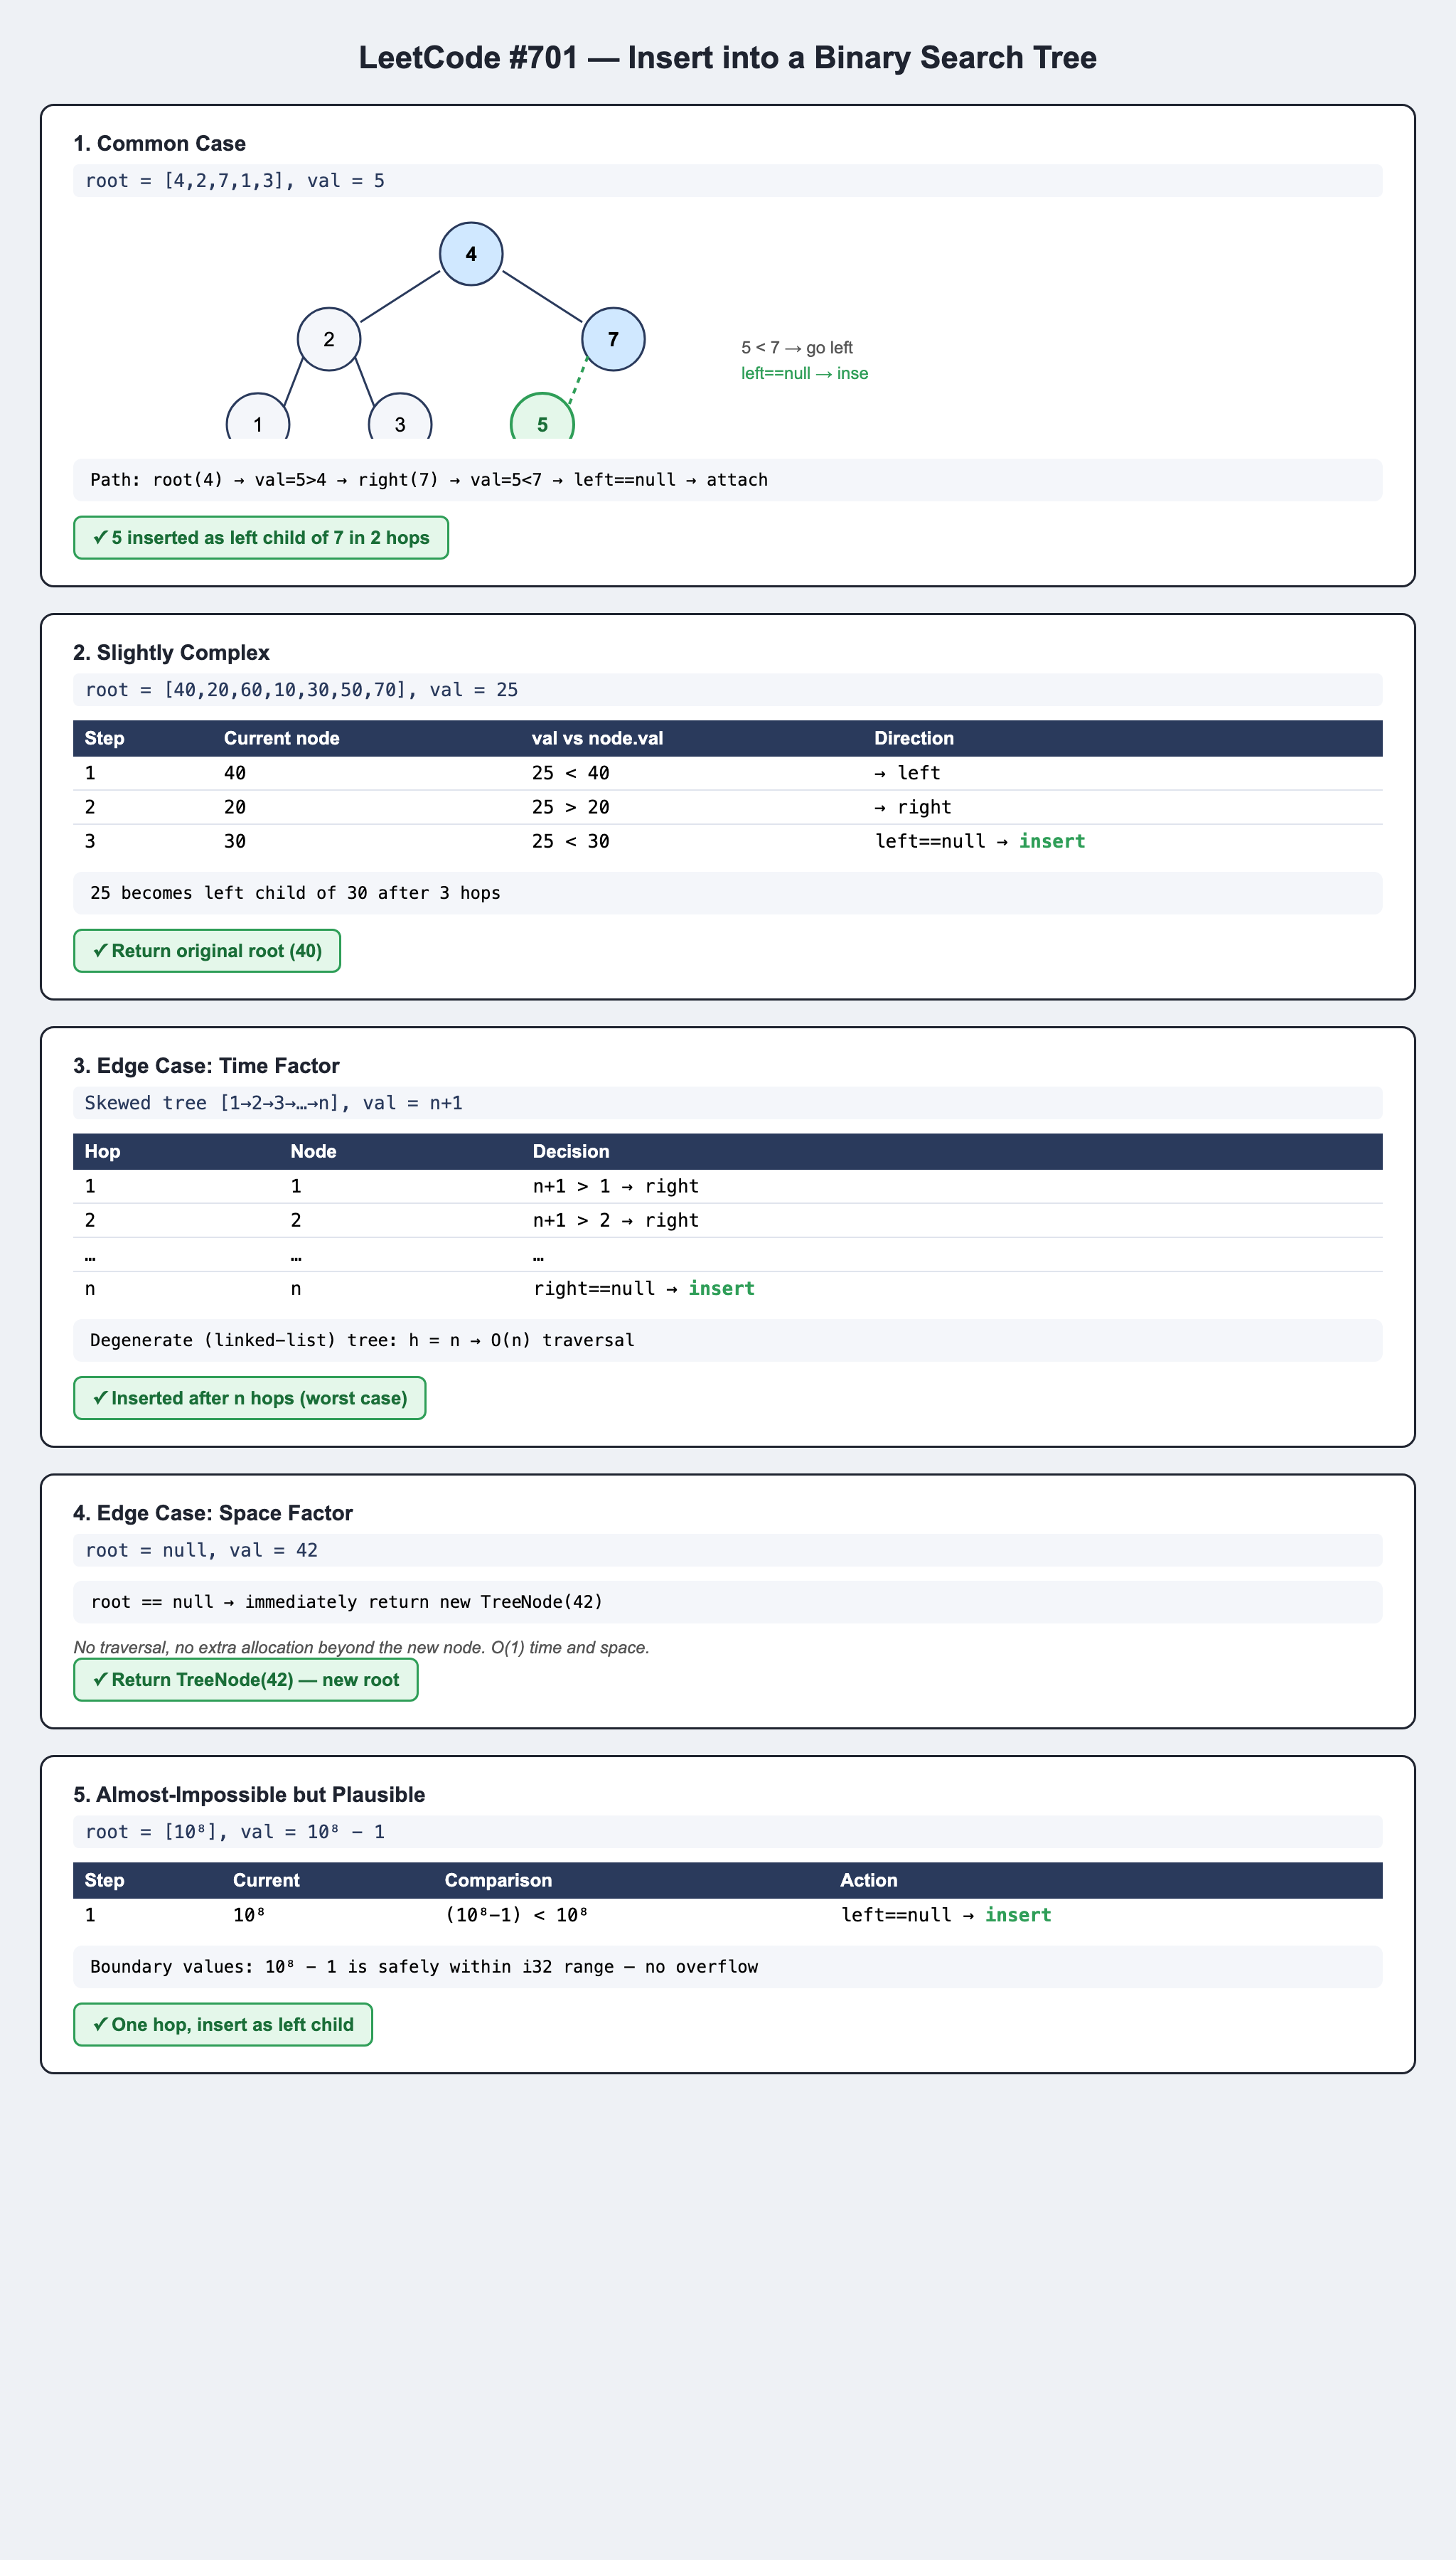